In [1]:
!module list 2>/dev/null || true
!nvidia-smi 2>/dev/null || true
!which mpirun 2>/dev/null || true
!which python3
%env HOROVOD_GPU_ALLREDUCE=NCCL
%env HOROVOD_GPU_ALLGATHER=NCCL
%env HOROVOD_GPU_BROADCAST=NCCL
%env NCCL_DEBUG=DEBUG

In [2]:
!nvidia-smi -L 2>/dev/null || echo 'No GPU or nvidia-smi available in current environment'

In [3]:
try:
    import horovod
    from horovod import run
    has_horovod = True
except (ImportError, ModuleNotFoundError):
    has_horovod = False
    run = None

def dummy(
    epochs=50,
    batch_size=8,
    base_channels=32,
    levels=4,
    attention=True,
    attention_heads=4,
    sigma_min=1e-4,
    lambda_velocity=1.0,
    sampler="heun",
    solver_steps=10,
    shrink=16,
    sample_limit=None,
):
    #----------------------------------------
    # Import packages
    #----------------------------------------
    import sys
    import os
    os.environ["TF_DISABLE_NVTX_RANGES"] = "1"
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    os.environ["NCCL_DEBUG"] = "WARN"
    import time
    import socket
    import math
    import numpy as np
    import xarray as xr
    try:
        import dask
        import dask.array as da
    except (ImportError, ModuleNotFoundError):
        pass
    try:
        import zarr as zr
    except (ImportError, ModuleNotFoundError):
        pass
    import pickle
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
    from tensorflow import keras
    from tensorflow.keras import layers, models, losses
    from tensorflow.keras.optimizers import Optimizer
    
    # Set logging level
    tf.get_logger().setLevel(tf.compat.v1.logging.ERROR)
    
    #------------------------------------------------------------
    # Initialise Horovod (with single-process fallback)
    #------------------------------------------------------------
    try:
        import horovod.tensorflow.keras as hvd
        hvd.init()
        has_hvd = True
    except Exception as e:
        has_hvd = False
        class DummyHVD:
            def size(self): return 1
            def rank(self): return 0
            def local_rank(self): return 0
            def allreduce(self, val, name=None): return val
        hvd = DummyHVD()
    
    # Pin GPU
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    if gpus and has_hvd:
        tf.config.experimental.set_visible_devices(gpus[hvd.local_rank()], 'GPU')
    
    #------------------------------------------------------------
    # Data Loading (xarray)
    #------------------------------------------------------------
    gadi_data_path = "/g/data/sd82/OFAM_AUSTRALIA/sst_10km_OFAM_historical_Australia.nc"
    local_data_path = "/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/sst_10km_OFAM_historical_Australia.nc"
    
    if os.path.exists(gadi_data_path):
        data_path = gadi_data_path
    elif os.path.exists(local_data_path):
        data_path = local_data_path
    else:
        raise FileNotFoundError(f"Could not find SST dataset at {gadi_data_path} or {local_data_path}")
    
    print(f"Loading dataset from {data_path} using xarray (decode_times=False)...")
    ds = xr.open_dataset(data_path, decode_times=False)
    sst = ds["temp"] if "temp" in ds else ds[list(ds.data_vars.keys())[0]]
    if "st_ocean" in sst.dims and sst.sizes["st_ocean"] == 1:
        sst = sst.squeeze("st_ocean")
    
    total_time = sst.shape[0]
    print(f"Total available time steps in dataset: {total_time}")
    
    if sample_limit is not None and sample_limit > 0:
        train_samples = min(sample_limit, total_time)
    else:
        train_samples = min(1000, total_time)
    
    print(f"Loading slice of {train_samples} time steps...")
    raw_data = np.asarray(sst[:train_samples, :, :].values, dtype=np.float32)
    print("Loaded raw data shape:", raw_data.shape)
    
    # Binary land mask (1 for ocean, 0 for land/NaN)
    nan_mask = np.isnan(raw_data)
    ocean_mask_single = (~np.isnan(raw_data[0])).astype(np.float32)
    raw_data = np.nan_to_num(raw_data, nan=0.0)
    
    # Normalisation parameters
    sst_min = np.min(raw_data[~nan_mask]) if np.any(~nan_mask) else 0.0
    sst_max = np.max(raw_data[~nan_mask]) if np.any(~nan_mask) else 35.0
    print(f"SST ocean range: min={sst_min:.2f} C, max={sst_max:.2f} C")
    norm_data = np.where(~nan_mask, (raw_data - sst_min) / (sst_max - sst_min + 1e-6), 0.0).astype(np.float32)
    
    H_fine, W_fine = norm_data.shape[1], norm_data.shape[2]
    H_coarse = H_fine // shrink
    W_coarse = W_fine // shrink
    print(f"Resolution: High-Res ({H_fine}x{W_fine}), Coarse ({H_coarse}x{W_coarse})")
    
    # Coarsen via block average over ocean
    N = len(norm_data)
    fine_targets = norm_data[:, :, :, np.newaxis] # (N, H, W, 1)
    fine_masks = np.repeat(ocean_mask_single[np.newaxis, :, :, np.newaxis], N, axis=0) # (N, H, W, 1)
    
    reshaped = norm_data.reshape(N, H_coarse, shrink, W_coarse, shrink)
    mask_reshaped = fine_masks[:, :, :, 0].reshape(N, H_coarse, shrink, W_coarse, shrink)
    ocean_counts = mask_reshaped.sum(axis=(2, 4))
    ocean_fraction = ocean_counts / float(shrink * shrink)
    coarse_sst = np.where(ocean_counts > 0, (reshaped * mask_reshaped).sum(axis=(2, 4)) / np.maximum(ocean_counts, 1.0), 0.0)
    coarse_conditions = np.stack([coarse_sst, ocean_fraction], axis=-1).astype(np.float32) # (N, H_c, W_c, 2)
    
    # Train / Test split (80% train, 20% test)
    split_idx = int(0.8 * N)
    train_cond = coarse_conditions[:split_idx]
    train_mask = fine_masks[:split_idx]
    train_target = fine_targets[:split_idx]
    
    test_cond = coarse_conditions[split_idx:]
    test_mask = fine_masks[split_idx:]
    test_target = fine_targets[split_idx:]
    
    print(f"Train samples: {len(train_target)}, Test samples: {len(test_target)}")
    
    #------------------------------------------------------------
    # Flow Matching Architecture (TensorFlow Keras)
    #------------------------------------------------------------
    def group_count(channels: int) -> int:
        for cand in (32, 16, 8, 4, 2):
            if channels % cand == 0 and channels // cand >= 4:
                return cand
        return 1

    class TimeEmbeddingTF(layers.Layer):
        def __init__(self, dimension: int, **kwargs):
            super().__init__(**kwargs)
            self.dimension = dimension
            self.fc1 = layers.Dense(dimension * 2)
            self.fc2 = layers.Dense(dimension)

        def call(self, flow_time):
            half = self.dimension // 2
            freqs = tf.exp(-math.log(10000.0) * tf.range(half, dtype=tf.float32) / max(half - 1, 1))
            flow_time = tf.cast(tf.reshape(flow_time, (-1, 1)), tf.float32)
            angles = flow_time * 1000.0 * freqs[None, :]
            emb = tf.concat([tf.sin(angles), tf.cos(angles)], axis=-1)
            return self.fc2(tf.nn.silu(self.fc1(emb)))

    class ChannelAttentionTF(layers.Layer):
        def __init__(self, channels: int, reduction: int = 16, **kwargs):
            super().__init__(**kwargs)
            hidden = max(channels // reduction, 8)
            self.fc1 = layers.Conv2D(hidden, 1, use_bias=False)
            self.fc2 = layers.Conv2D(channels, 1, use_bias=False)

        def call(self, values):
            avg_pool = tf.reduce_mean(values, axis=[1, 2], keepdims=True)
            max_pool = tf.reduce_max(values, axis=[1, 2], keepdims=True)
            w = self.fc2(tf.nn.relu(self.fc1(avg_pool))) + self.fc2(tf.nn.relu(self.fc1(max_pool)))
            return values * tf.sigmoid(w)

    class ResidualBlockTF(layers.Layer):
        def __init__(self, output_channels: int, time_dimension: int, **kwargs):
            super().__init__(**kwargs)
            self.output_channels = output_channels
            self.groups_out = group_count(output_channels)
            self.conv1 = layers.Conv2D(output_channels, 3, padding="same")
            self.conv2 = layers.Conv2D(output_channels, 3, padding="same",
                                       kernel_initializer="zeros", bias_initializer="zeros")
            self.time_proj = layers.Dense(output_channels * 2)
            self.ca = ChannelAttentionTF(output_channels)
            self.norm2 = layers.GroupNormalization(groups=self.groups_out)
            self.norm1 = None
            self.skip_conv = None

        def build(self, input_shape):
            in_channels = input_shape[-1]
            self.norm1 = layers.GroupNormalization(groups=group_count(in_channels))
            if in_channels != self.output_channels:
                self.skip_conv = layers.Conv2D(self.output_channels, 1, padding="same")
            super().build(input_shape)

        def call(self, values, time_emb):
            h = self.conv1(tf.nn.silu(self.norm1(values)))
            proj = self.time_proj(time_emb)
            scale, shift = tf.split(proj, 2, axis=-1)
            h = self.norm2(h) * (1.0 + scale[:, None, None, :]) + shift[:, None, None, :]
            h = self.conv2(tf.nn.silu(h))
            h = self.ca(h)
            skip = self.skip_conv(values) if self.skip_conv is not None else values
            return h + skip

    class SelfAttentionTF(layers.Layer):
        def __init__(self, channels: int, heads: int = 4, **kwargs):
            super().__init__(**kwargs)
            self.channels = channels
            self.heads = heads
            self.head_dim = channels // heads
            self.norm = layers.GroupNormalization(groups=group_count(channels))
            self.qkv = layers.Conv2D(channels * 3, 1, padding="same")
            self.out_conv = layers.Conv2D(channels, 1, padding="same",
                                          kernel_initializer="zeros", bias_initializer="zeros")

        def call(self, values):
            B = tf.shape(values)[0]
            H = tf.shape(values)[1]
            W = tf.shape(values)[2]
            qkv = self.qkv(self.norm(values))
            q, k, v = tf.split(qkv, 3, axis=-1)
            q = tf.transpose(tf.reshape(q, (B, H * W, self.heads, self.head_dim)), [0, 2, 1, 3])
            k = tf.transpose(tf.reshape(k, (B, H * W, self.heads, self.head_dim)), [0, 2, 1, 3])
            v = tf.transpose(tf.reshape(v, (B, H * W, self.heads, self.head_dim)), [0, 2, 1, 3])
            scale = 1.0 / math.sqrt(self.head_dim)
            scores = tf.matmul(q, k, transpose_b=True) * scale
            weights = tf.nn.softmax(scores, axis=-1)
            att = tf.matmul(weights, v)
            att = tf.reshape(tf.transpose(att, [0, 2, 1, 3]), (B, H, W, self.channels))
            return values + self.out_conv(att)

    class FlowUNetTF(keras.Model):
        def __init__(self, base_channels: int = 32, levels: int = 4,
                     condition_channels: int = 2, target_channels: int = 1,
                     attention: bool = True, attention_heads: int = 4, **kwargs):
            super().__init__(**kwargs)
            self.levels = levels
            time_dim = base_channels * 8
            channels = [base_channels * min(2**lvl, 8) for lvl in range(levels)]
            self.time_emb = TimeEmbeddingTF(time_dim)
            self.input_block = ResidualBlockTF(channels[0], time_dim)
            self.down = [ResidualBlockTF(channels[lvl], time_dim) for lvl in range(1, levels)]
            self.middle1 = ResidualBlockTF(channels[-1], time_dim)
            self.attention = SelfAttentionTF(channels[-1], attention_heads) if attention else layers.Layer()
            self.middle2 = ResidualBlockTF(channels[-1], time_dim)
            self.up = [ResidualBlockTF(channels[lvl - 1], time_dim) for lvl in range(levels - 1, 0, -1)]
            self.out_norm = layers.GroupNormalization(groups=group_count(channels[0]))
            self.out_conv = layers.Conv2D(target_channels, 1, padding="same",
                                          kernel_initializer="zeros", bias_initializer="zeros")

        def call(self, inputs, training=None):
            state, condition, mask, flow_time = inputs
            H, W = tf.shape(state)[1], tf.shape(state)[2]
            emb = self.time_emb(flow_time)
            cond_up = tf.image.resize(condition, (H, W), method="bilinear")
            x = tf.concat([state, cond_up, mask], axis=-1)
            h = self.input_block(x, emb)
            skips = [h]

            for lvl, down_block in enumerate(self.down):
                h_pool = tf.nn.avg_pool2d(h, 2, 2, padding="SAME")
                H_p, W_p = tf.shape(h_pool)[1], tf.shape(h_pool)[2]
                cond_p = tf.image.resize(condition, (H_p, W_p), method="bilinear")
                h = down_block(tf.concat([h_pool, cond_p], axis=-1), emb)
                skips.append(h)

            h_mid = tf.nn.avg_pool2d(h, 2, 2, padding="SAME")
            H_m, W_m = tf.shape(h_mid)[1], tf.shape(h_mid)[2]
            cond_m = tf.image.resize(condition, (H_m, W_m), method="bilinear")
            h = self.middle1(tf.concat([h_mid, cond_m], axis=-1), emb)
            h = self.attention(h)
            h = self.middle2(h, emb)

            for idx, up_block in enumerate(self.up):
                skip = skips[self.levels - 2 - idx]
                H_s, W_s = tf.shape(skip)[1], tf.shape(skip)[2]
                h = tf.image.resize(h, (H_s, W_s), method="bilinear")
                h = up_block(tf.concat([h, skip], axis=-1), emb)

            out = self.out_conv(tf.nn.silu(self.out_norm(h)))
            return out * mask

    def masked_mse(pred, target, mask):
        diff_sq = tf.square(pred - target) * mask
        denom = tf.maximum(tf.reduce_sum(mask), 1.0)
        return tf.reduce_sum(diff_sq) / denom

    class FlowMatchingTrainer(keras.Model):
        def __init__(self, velocity_net, sigma_min=1e-4, lambda_velocity=1.0, **kwargs):
            super().__init__(**kwargs)
            self.velocity_net = velocity_net
            self.sigma_min = float(sigma_min)
            self.lambda_velocity = float(lambda_velocity)
            self.loss_tracker = keras.metrics.Mean(name="velocity_loss")

        def compile(self, optimizer):
            super().compile()
            self.optimizer = optimizer

        @property
        def metrics(self):
            return [self.loss_tracker]

        def train_step(self, data):
            if len(data) == 2:
                (condition, mask), target = data
            else:
                condition, mask = data[0]
                target = data[1]

            B = tf.shape(target)[0]
            H = tf.shape(target)[1]
            W = tf.shape(target)[2]

            flow_time = tf.random.uniform((B,), minval=0.0, maxval=1.0, dtype=target.dtype)
            noise = tf.random.normal((B, H, W, 1), dtype=target.dtype) * mask
            t_w = flow_time[:, None, None, None]
            state = (1.0 - (1.0 - self.sigma_min) * t_w) * noise + t_w * target
            state = state * mask
            target_velocity = (target - (1.0 - self.sigma_min) * noise) * mask

            with tf.GradientTape() as tape:
                pred_velocity = self.velocity_net((state, condition, mask, flow_time), training=True)
                loss = self.lambda_velocity * masked_mse(pred_velocity, target_velocity, mask)

            grads = tape.gradient(loss, self.velocity_net.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 1.0)
            self.optimizer.apply_gradients(zip(grads, self.velocity_net.trainable_variables))
            self.loss_tracker.update_state(loss)
            return {"velocity_loss": self.loss_tracker.result()}

        def test_step(self, data):
            if len(data) == 2:
                (condition, mask), target = data
            else:
                condition, mask = data[0]
                target = data[1]

            B = tf.shape(target)[0]
            H = tf.shape(target)[1]
            W = tf.shape(target)[2]

            flow_time = tf.random.uniform((B,), minval=0.0, maxval=1.0, dtype=target.dtype)
            noise = tf.random.normal((B, H, W, 1), dtype=target.dtype) * mask
            t_w = flow_time[:, None, None, None]
            state = (1.0 - (1.0 - self.sigma_min) * t_w) * noise + t_w * target
            state = state * mask
            target_velocity = (target - (1.0 - self.sigma_min) * noise) * mask

            pred_velocity = self.velocity_net((state, condition, mask, flow_time), training=False)
            loss = self.lambda_velocity * masked_mse(pred_velocity, target_velocity, mask)
            self.loss_tracker.update_state(loss)
            return {"velocity_loss": self.loss_tracker.result()}

        def sample(self, condition, mask, steps=10, sampler="heun"):
            B = tf.shape(condition)[0]
            H = tf.shape(mask)[1]
            W = tf.shape(mask)[2]
            state = tf.random.normal((B, H, W, 1), dtype=condition.dtype) * mask
            dt = 1.0 / float(steps)

            for step in range(steps):
                t_val = float(step) / float(steps)
                t_tensor = tf.fill((B,), t_val)
                v1 = self.velocity_net((state, condition, mask, t_tensor), training=False)
                if sampler == "heun" and step < steps - 1:
                    next_state = (state + dt * v1) * mask
                    t_next = tf.fill((B,), t_val + dt)
                    v2 = self.velocity_net((next_state, condition, mask, t_next), training=False)
                    state = (state + 0.5 * dt * (v1 + v2)) * mask
                else:
                    state = (state + dt * v1) * mask
            return state

    # Instantiate model
    unet = FlowUNetTF(
        base_channels=base_channels,
        levels=levels,
        condition_channels=2,
        target_channels=1,
        attention=attention,
        attention_heads=attention_heads,
    )
    
    # Build model by calling with dummy batch
    t_dummy = tf.constant([0.5], dtype=tf.float32)
    _ = unet((train_target[:1], train_cond[:1], train_mask[:1], t_dummy))
    print(f"Flow Matching Velocity UNet total trainable parameters: {unet.count_params():,}")
    
    trainer = FlowMatchingTrainer(unet, sigma_min=sigma_min, lambda_velocity=lambda_velocity)
    lr_scale = hvd.size() if has_hvd else 1.0
    optimizer = keras.optimizers.Adam(learning_rate=0.0001 * lr_scale)
    trainer.compile(optimizer=optimizer)
    
    callbacks = []
    if hvd.rank() == 0:
        callbacks.append(keras.callbacks.EarlyStopping(monitor='val_velocity_loss', patience=10, restore_best_weights=False, verbose=1))
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_velocity_loss', factor=0.5, patience=5, verbose=1))
    
    print("Starting Flow Matching standard model.fit training...")
    start_time = time.time()
    history = trainer.fit(
        x=(train_cond, train_mask),
        y=train_target,
        validation_data=((test_cond, test_mask), test_target),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2 if hvd.rank() == 0 else 0,
    )
    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f} seconds.")
    
    return {
        "unet": unet,
        "trainer": trainer,
        "history": history.history if hasattr(history, 'history') else {},
        "train_data": (train_cond, train_mask, train_target),
        "test_data": (test_cond, test_mask, test_target),
        "norm": (sst_min, sst_max),
    }

In [4]:
# Train Flow Matching model with standard arguments
results = dummy(
    epochs=5,
    batch_size=4,
    base_channels=32,
    levels=4,
    attention=True,
    attention_heads=4,
    sigma_min=1e-4,
    lambda_velocity=1.0,
    sampler="heun",
    solver_steps=10,
    sample_limit=16,
)

TensorFlow version: 2.15.1
Loading dataset from /esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/sst_10km_OFAM_historical_Australia.nc using xarray (decode_times=False)...
Total available time steps in dataset: 13149
Loading slice of 16 time steps...
Loaded raw data shape: (16, 512, 512)
SST ocean range: min=4.87 C, max=36.46 C
Resolution: High-Res (512x512), Coarse (32x32)
Train samples: 12, Test samples: 4
Flow Matching Velocity UNet total trainable parameters: 5,684,409
Starting Flow Matching standard model.fit training...
Epoch 1/5
3/3 - 53s - velocity_loss: 1.3308 - val_velocity_loss: 1.3281 - lr: 1.0000e-04 - 53s/epoch - 18s/step
Epoch 2/5
3/3 - 30s - velocity_loss: 1.3223 - val_velocity_loss: 1.3221 - lr: 1.0000e-04 - 30s/epoch - 10s/step
Epoch 3/5
3/3 - 30s - velocity_loss: 1.3186 - val_velocity_loss: 1.3122 - lr: 1.0000e-04 - 30s/epoch - 10s/step
Epoch 4/5
3/3 - 30s - velocity_loss: 1.3088 - val_velocity_loss: 1.3057 - lr: 1.0000e-04 - 30s/epoch - 10s/step
Epoch

In [5]:
# Multi-GPU Horovod execution (if available)
if has_horovod and run is not None:
    print("Running distributed training with Horovod...")
    # run(dummy, np=4, args=(50, 8, 32, 4, True, 4, 1e-4, 1.0, 'heun', 10, 16, None))
else:
    print("Single-process mode active. Horovod multi-GPU execution available when invoked under mpirun/hvd.")

Single-process mode active. Horovod multi-GPU execution available when invoked under mpirun/hvd.


Running Heun ODE solver integration (10 steps)...
Evaluated sample 0: Ocean MAE = 28.8378 C, Ocean RMSE = 36.0278 C


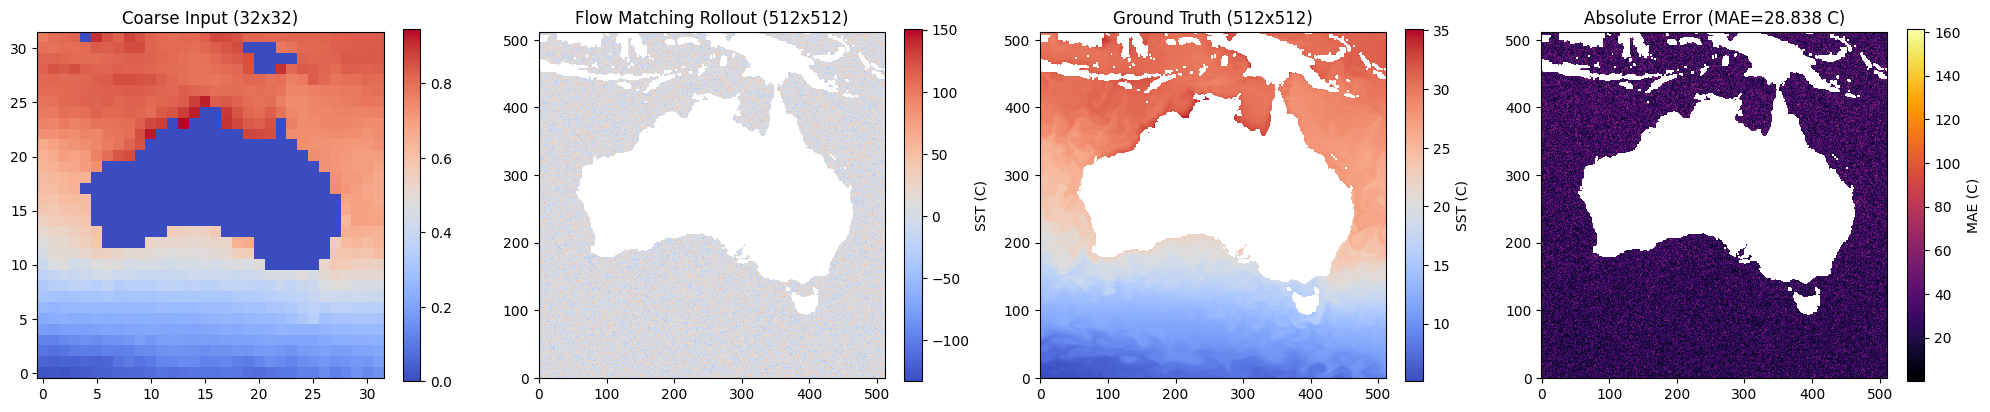

In [6]:
import matplotlib.pyplot as plt
import numpy as np

if 'results' in locals() and 'trainer' in results:
    trainer = results['trainer']
    test_cond, test_mask, test_target = results['test_data']
    sst_min, sst_max = results['norm']
    
    sample_idx = 0
    print("Running Heun ODE solver integration (10 steps)...")
    sampled_norm = trainer.sample(test_cond[sample_idx:sample_idx+1], test_mask[sample_idx:sample_idx+1], steps=10, sampler="heun").numpy()[0, :, :, 0]
    targ_norm = test_target[sample_idx, :, :, 0]
    cond_norm = test_cond[sample_idx, :, :, 0]
    mask = test_mask[sample_idx, :, :, 0]
    
    # Denormalise
    pred_phys = np.where(mask > 0.5, sampled_norm * (sst_max - sst_min) + sst_min, np.nan)
    targ_phys = np.where(mask > 0.5, targ_norm * (sst_max - sst_min) + sst_min, np.nan)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    im0 = axes[0].imshow(cond_norm, cmap='coolwarm', origin='lower')
    axes[0].set_title("Coarse Input (32x32)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    im1 = axes[1].imshow(pred_phys, cmap='coolwarm', origin='lower')
    axes[1].set_title(f"Flow Matching Rollout ({pred_phys.shape[0]}x{pred_phys.shape[1]})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='SST (C)')
    
    im2 = axes[2].imshow(targ_phys, cmap='coolwarm', origin='lower')
    axes[2].set_title(f"Ground Truth ({targ_phys.shape[0]}x{targ_phys.shape[1]})")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='SST (C)')
    
    err = np.where(mask > 0.5, np.abs(pred_phys - targ_phys), np.nan)
    im3 = axes[3].imshow(err, cmap='inferno', origin='lower')
    axes[3].set_title(f"Absolute Error (MAE={np.nanmean(err):.3f} C)")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, label='MAE (C)')
    
    plt.tight_layout()
    plt.savefig("/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/SRDN/sst_flow_stand_eval.png", dpi=150)
    plt.show()
    print(f"Evaluated sample {sample_idx}: Ocean MAE = {np.nanmean(err):.4f} C, Ocean RMSE = {np.sqrt(np.nanmean(err**2)):.4f} C")
else:
    print("Results not available for visualization.")